In [1]:

import jax
import jax.numpy as jnp
from flax import nnx

from probjax.nn.nets.flows import AdditiveCouplingFlow, AffineAutoregressiveFlow
from probjax.nn.nets.autoregressive import AutoregressiveMLP


In [2]:
p = AffineAutoregressiveFlow(4, 5, nnx.Rngs(1))

graph_def, params, state = nnx.split(p, nnx.Param,...)


In [3]:
x1 = jax.random.normal(jax.random.PRNGKey(0), (1000, 4)) -2
x2 = jax.random.normal(jax.random.PRNGKey(1), (1000, 4)) +2

xs = jnp.concatenate([x1, x2], axis=0)

In [4]:
xs.shape

(2000, 4)

In [5]:
def loss(params):
    p = nnx.merge(graph_def, params, state)
    return -jnp.mean(p.logpdf(xs))

In [6]:
loss(params)

Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}


Array(24.037, dtype=float32)

In [7]:
import optax

optimizer = optax.adam(1e-3)

@jax.jit
def update(params, opt_state):
    loss_val, grads = jax.value_and_grad(loss)(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return loss_val, new_params, opt_state

In [8]:
opt_state = optimizer.init(params)

In [9]:
for i in range(1000):
    loss_val, params, opt_state = update(params, opt_state)
    print(loss_val)

Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
24.03669
23.996342
23.955435
23.913855
23.87151
23.82841
23.784376
23.739513
23.693626
23.646751
23.598639
23.549402
23.498827
23.44671
23.39318
23.337986
23.281078
23.222067
23.161213
23.098114
23.032532
22.964388
22.893663
22.81978
22.742943
22.66232
22.578112
22.48978
22.397293
22.29977
22.197079
22.088604
21.97388
21.85229
21.722954
21.585037
21.438278
21.28095
21.112192
20.931353
20.737343
20.528841
20.304438
20.064825
19.80787
19.534472
19.244106
18.93552
18.609535
18.265005
17.90197
17.52533
17.15377
16.81752
16.5116
16.191324
15.8372555
15.479415
15.154855
14.870266
14.609512
14.379975
14.158778
13.9096155
13.642966
13.391272
13.180245
12.986784
12.797065
12.611227
12.412548
12.186149
11.935769
11.677359
11.424901
11.

In [10]:
nnx.update(p, params)

In [11]:
samples = p.sample(jax.random.PRNGKey(0), (1000, ))

Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}
Traced<float32[4]>with<DynamicJaxprTrace> (None,) {}


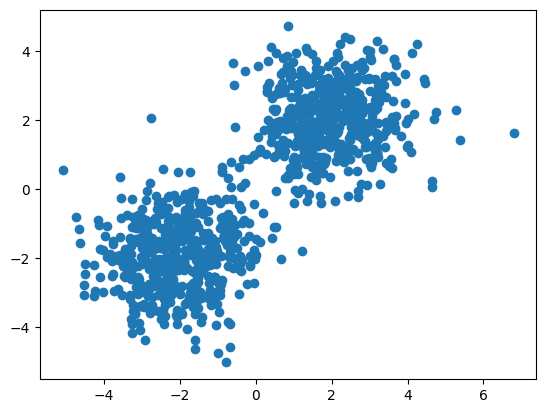

In [12]:
import matplotlib.pyplot as plt

plt.scatter(samples[:, 0], samples[:, 1])